Sales data: productid, customer_id, channel
Customers_data: customer_id
markerting: channel



---



M!: en attente

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Définition des chemins
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data" / "input"

# Chargement des données
customers = pd.read_csv(DATA_DIR / "customers_data.csv")
products = pd.read_csv(DATA_DIR / "products_data.csv")
sales = pd.read_csv(DATA_DIR / "sales_data.csv")
marketing = pd.read_csv(DATA_DIR / "marketing_data.csv")

#M2 Exploration des donnees

In [4]:
#Nettoyage

sales.info()
sales.describe()
sales.isna().sum()
sales.duplicated().sum()

products.info()
products.describe()
products.isna().sum()
products.duplicated().sum()

customers.info()
customers.describe()
customers.isna().sum()
customers.duplicated().sum()

marketing.info()
marketing.describe()
marketing.isna().sum()
marketing.duplicated().sum()

#Fusion des donnees

sales_full = sales.merge(customers, on='Customer_ID', how='inner')
sales_full = sales_full.merge(products, on='Product_ID', how='inner')

sales_full['Sale_Price'] = sales_full['Quantity'] * sales_full['Price']
total_spent_per_customer = sales_full.groupby('Customer_ID')['Sale_Price'].sum()
sales_full['Total_Spent'] = sales_full['Customer_ID'].map(total_spent_per_customer).fillna(0)
customers['Total_Spent'] = customers['Customer_ID'].map(total_spent_per_customer).fillna(0)

sales_full.info()
sales_full.head()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sale_ID      10000 non-null  int64  
 1   Product_ID   10000 non-null  str    
 2   Customer_ID  10000 non-null  int64  
 3   Date         10000 non-null  str    
 4   Quantity     10000 non-null  int64  
 5   Sale_Price   10000 non-null  float64
 6   Channel      10000 non-null  str    
dtypes: float64(1), int64(3), str(3)
memory usage: 547.0 KB
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_ID    100 non-null    str    
 1   Product_Name  100 non-null    str    
 2   Category      100 non-null    str    
 3   Price         100 non-null    float64
dtypes: float64(1), str(3)
memory usage: 3.3 KB
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data 

,Sale_ID,Product_ID,Customer_ID,Date,Quantity,Sale_Price,Channel,Name,Age,Gender,Location,Join_Date,Total_Spent,Product_Name,Category,Price
0,1,P037,2002,2023-01-01,1,139.80,Online,Manon,43,Male,Nice,2023-01-01,1812.03,Parka Imperméable,Outerwear,139.80
1,2,P079,2002,2023-01-01,2,159.80,Store,Manon,43,Male,Nice,2023-01-01,1812.03,Chemise Habillée,Formalwear,79.90
2,3,P034,2002,2023-01-01,2,87.34,Online,Manon,43,Male,Nice,2023-01-01,1812.03,Doudoune Légère,Outerwear,43.67
3,4,P080,2004,2023-01-01,1,99.50,Online,Grace,36,Male,Philadelphia,2023-01-01,2052.80,Pantalon de Costume,Formalwear,99.50
4,5,P035,2001,2023-01-01,1,39.55,Online,Charlie,30,Male,San Antonio,2023-01-01,1829.97,Coupe-Vent,Outerwear,39.55


M2: Exploration des donnees

Donnees: sales_data, products_data, customers_data

Objectif: Graph


*   Meilleurs client
*   Produit le plus vendu
*   Rapport Channel/vente
*   Category le plus vendu
*   Rapport age/vente



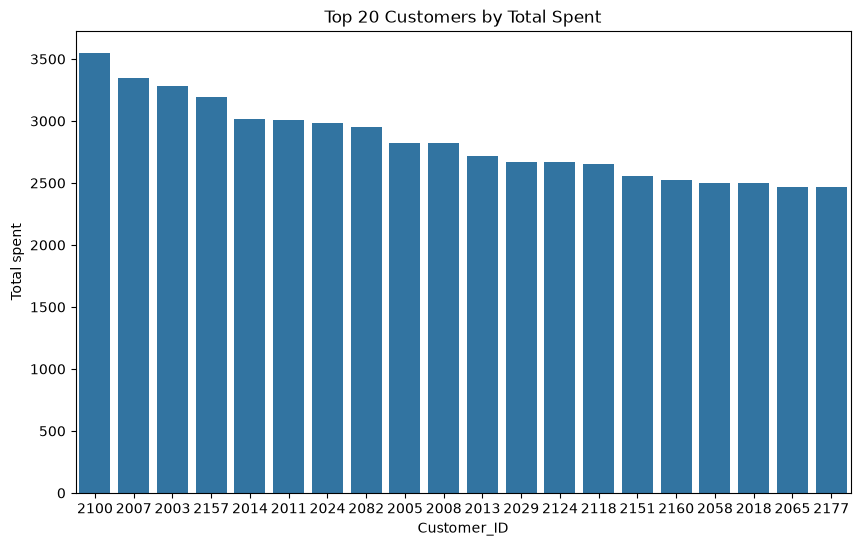

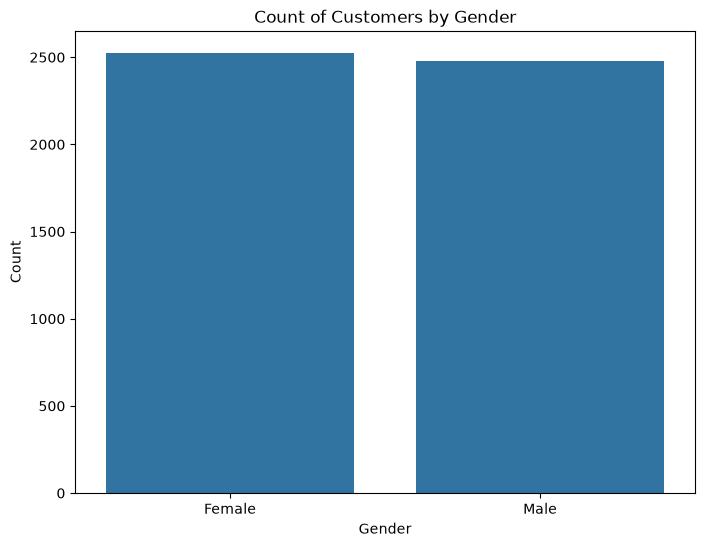

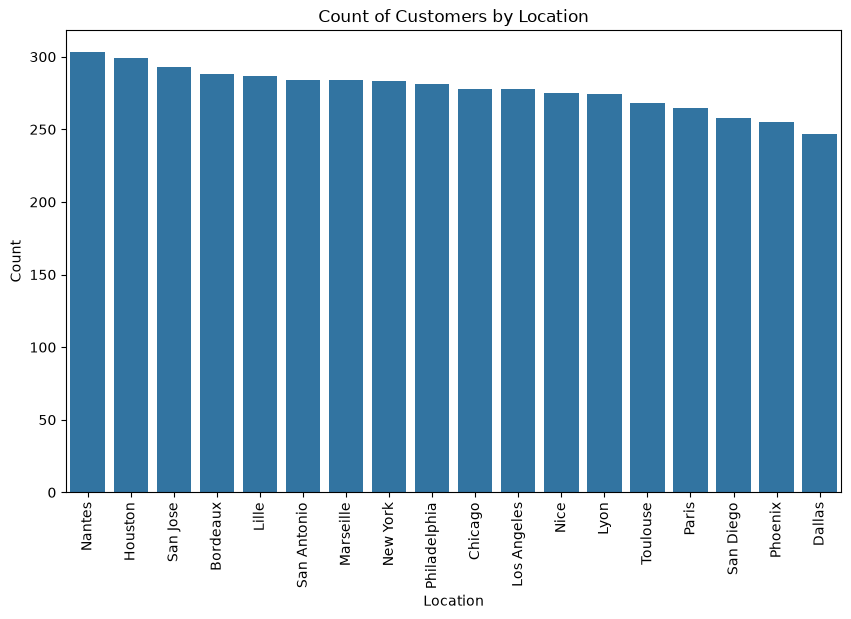

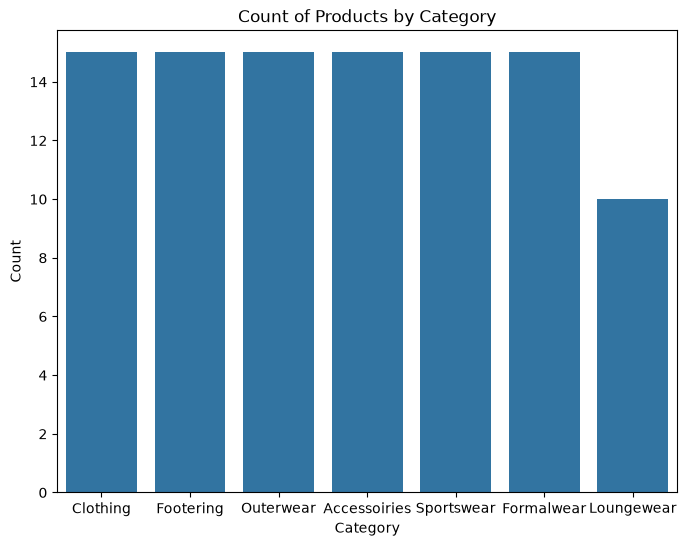

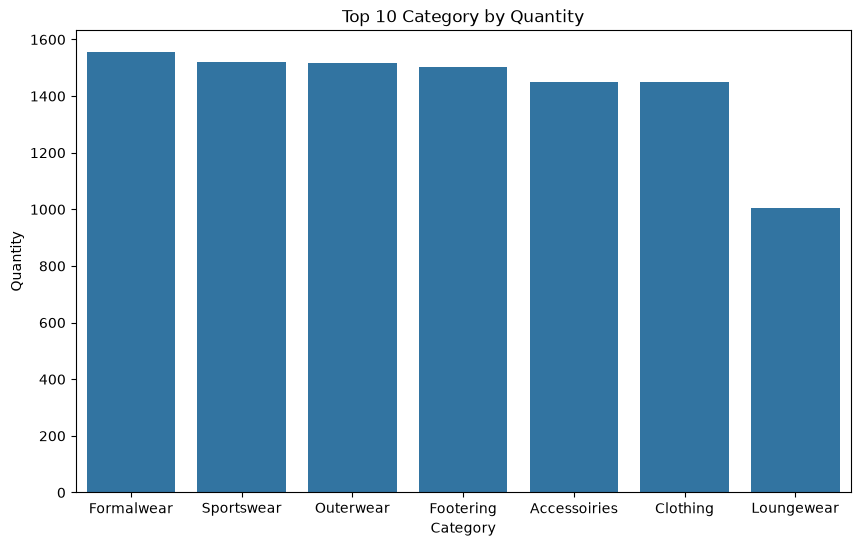

<function matplotlib.pyplot.show(close=None, block=None)>

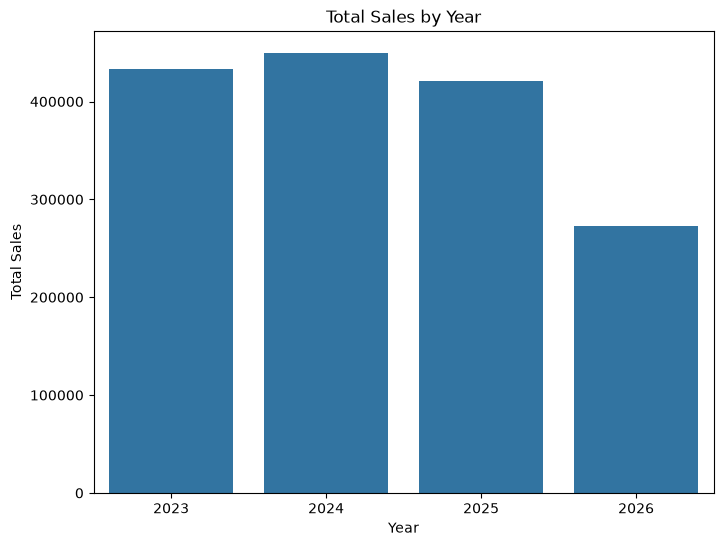

In [5]:
from matplotlib import pyplot as plt
import seaborn as sns

# Top 20 meilleurs client

top_customers = customers.sort_values(by='Total_Spent', ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(y='Total_Spent', x='Customer_ID', data=top_customers, order=top_customers['Customer_ID'])
plt.xlabel('Customer_ID')
plt.ylabel('Total spent')
plt.title('Top 20 Customers by Total Spent')
plt.show()

# Total client par genre

gender_counts = customers['Gender'].value_counts()
plt.figure(figsize=(8, 6))
sns.barplot(x=gender_counts.index, y=gender_counts.values)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Count of Customers by Gender')
plt.show()

# Total client par Location

location_counts = customers['Location'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=location_counts.index, y=location_counts.values)
plt.xlabel('Location')
plt.ylabel('Count')
plt.title('Count of Customers by Location')
plt.xticks(rotation=90)
plt.show()

# Total produit par category

category_counts = products['Category'].value_counts()
plt.figure(figsize=(8, 6))
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Count of Products by Category')
plt.show()

# Category le plus vendu

top_products = sales_full['Category'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(y=top_products.values, x=top_products.index)
plt.xlabel('Category')
plt.ylabel('Quantity')
plt.title('Top 10 Category by Quantity')
plt.show()

# Total vente par annee

sales_full['Year'] = pd.to_datetime(sales_full['Date']).dt.year
yearly_sales = sales_full.groupby('Year')['Sale_Price'].sum()
plt.figure(figsize=(8, 6))
sns.barplot(x=yearly_sales.index, y=yearly_sales.values)
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.title('Total Sales by Year')
plt.show




#M3: Segmentation client

Créer des clusters de clients basés sur l'âge, les dépenses et les produits achetés

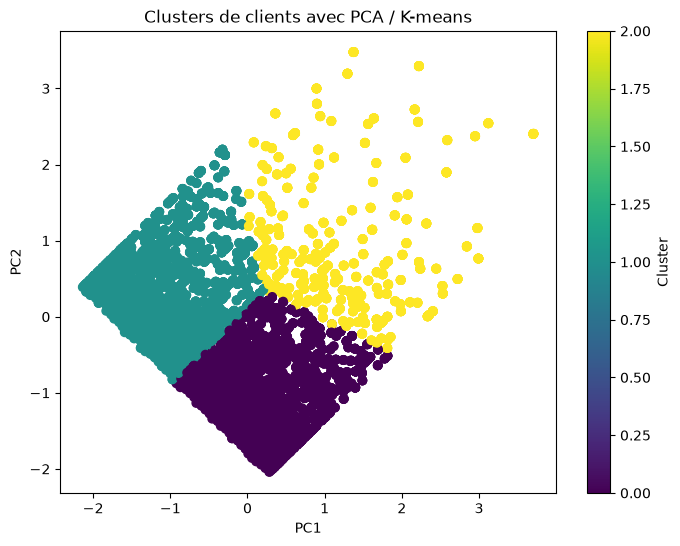

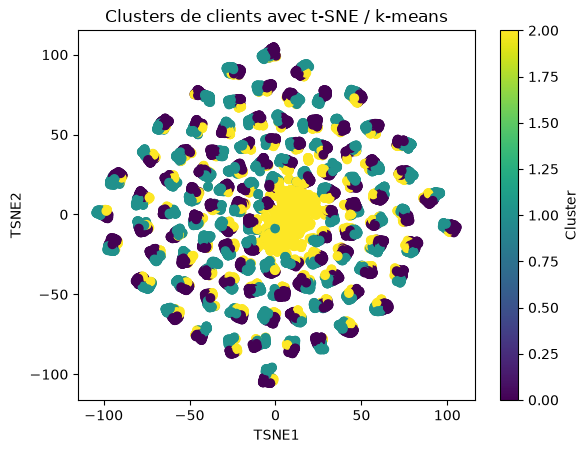

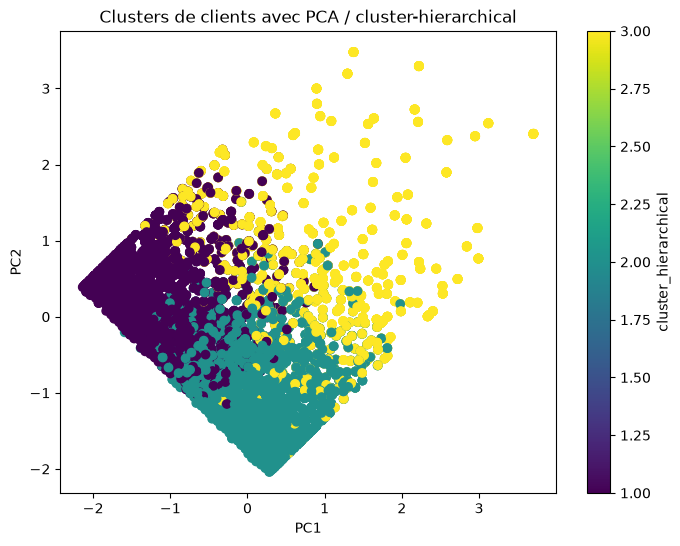

Silhouette Score : 0.17210445227635576


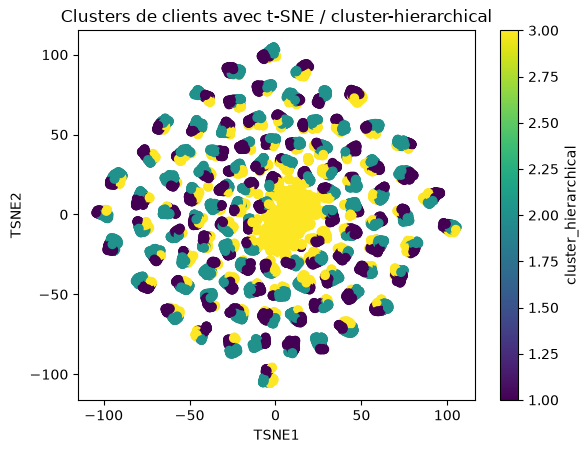

K-Means : 0.23876986468998412


In [6]:

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

customer_features = sales_full.copy()

features = ['Age', 'Total_Spent', 'Product_Name']
X = sales_full[features]

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', StandardScaler(), ['Age', 'Total_Spent']),
        ('product', OneHotEncoder(handle_unknown='ignore'), ['Product_Name'])
    ]
)

X_scaled = preprocessor.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(
     n_components=2,
     init="random",
     random_state=42
 )
X_tsne = tsne.fit_transform(X_scaled)


kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_features['cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=customer_features['cluster']
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clusters de clients avec PCA / K-means')
plt.colorbar(label='Cluster')

plt.show()

plt.scatter(
X_tsne[:, 0],
X_tsne[:, 1],
c=customer_features['cluster']
)

plt.xlabel('TSNE1')
plt.ylabel('TSNE2')
plt.title('Clusters de clients avec t-SNE / k-means')
plt.colorbar(label='Cluster')

plt.show()


# Clustering hiérarchique
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import fcluster

X_dense = X_scaled.toarray()

linked = linkage(X_dense, method='ward')
customer_features['cluster_hierarchical'] = fcluster(linked, 3, criterion='maxclust')

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=customer_features['cluster_hierarchical']
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clusters de clients avec PCA / cluster-hierarchical')
plt.colorbar(label='cluster_hierarchical')

plt.show()

score = silhouette_score(
    X_scaled,
    customer_features['cluster_hierarchical']
)

print("Silhouette Score :", score)

plt.scatter(
     X_tsne[:, 0],
     X_tsne[:, 1],
     c=customer_features['cluster_hierarchical']

 )

plt.xlabel('TSNE1')
plt.ylabel('TSNE2')
plt.title('Clusters de clients avec t-SNE / cluster-hierarchical')
plt.colorbar(label='cluster_hierarchical')

plt.show()

score_kmeans = silhouette_score(
    X_scaled,
    customer_features['cluster']
)

print("K-Means :", score_kmeans)


#Profilage des segments

Identifier les caractéristiques, préférences et personas de chaque segment

In [10]:
cluster_profiles = customer_features.groupby('cluster').agg({
    'Age': 'mean',
    'Total_Spent': 'mean',
    'Customer_ID': 'count',
}).rename(columns={'Customer_ID': 'segment_size'})

print("--- Profils des Segments (Personas) ---")
print(cluster_profiles)

cluster_names = {
    0: 'Client age faible à faible dépense',
    1: 'Clients age eleve  à moyenne dépense',
    2: 'Clients age moyenne a forte dépense'
}

customer_features['segment'] = (
    customer_features['cluster'].map(cluster_names)
)

--- Profils des Segments (Personas) ---
               Age  Total_Spent  segment_size
cluster                                      
0        29.290423   570.619723          4187
1        54.045134   579.447751          3833
2        38.265657  1814.455753          1980


#Analyse des performances des campagnes

Évaluer les KPIs : Taux de clics, impressions, conversions, ROI, CPC, CPA

In [12]:
marketing['CTR (%)'] = (marketing['Clicks'] / marketing['Impressions']) * 100
marketing['Conversion_Rate (%)'] = (marketing['Conversions'] / marketing['Clicks']) * 100
marketing['CPC'] = marketing['Budget'] / marketing['Clicks']
marketing['CPA'] = marketing['Budget'] / marketing['Conversions']
sales_sum = sales_full['Sale_Price'].sum()
# print(sales_sum)
marketing['ROI (%)'] = ((sales_sum - marketing['Budget']) / marketing['Budget']) * 100

print("\n--- Performances des Campagnes ---")
print(marketing[['Campaign_ID', 'Channel', 'CTR (%)', 'Conversion_Rate (%)', 'CPC', 'CPA', 'ROI (%)']])








--- Performances des Campagnes ---
   Campaign_ID   Channel   CTR (%)  Conversion_Rate (%)       CPC        CPA  \
0            1    Online  4.000000             7.500000  0.500000   6.666667   
1            2  In-Store  1.666667            20.000000  3.000000  15.000000   
2            3    Social  3.750000            13.333333  1.333333  10.000000   
3            4     Email  5.000000             5.000000  0.500000  10.000000   
4            5        TV  5.000000             8.333333  1.000000  12.000000   

      ROI (%)  
0  157520.216  
1  104980.144  
2   78710.108  
3  315140.432  
4   52440.072  


#M6: Prédiction de churn ou CLV

Modèles prédictifs sur la fidélité ou la valeur client (Customer Lifetime Value)

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

cutoff_date = pd.to_datetime('2026-07-01')

future_end = pd.to_datetime('2026-09-01')

sales['Date'] = pd.to_datetime(sales['Date'])

clients_futur = sales[
    (sales['Date'] >= cutoff_date) & (sales['Date'] < future_end)
]['Customer_ID'].unique()

df_target = pd.DataFrame({'Customer_ID': sales['Customer_ID'].unique()})
df_target['target'] = df_target['Customer_ID'].isin(clients_futur).astype(int)

sales['Date'] = pd.to_datetime(sales['Date'])
df_hist = sales[sales['Date'] < cutoff_date]

df_hist['Date'] = pd.to_datetime(df_hist['Date'])

features = df_hist.groupby('Customer_ID').agg(
    recence=('Date', lambda x: (cutoff_date - x.max()).days),
    frequence=('Product_ID', 'count'),
    montant_total=('Sale_Price', 'sum'),
    panier_moyen=('Sale_Price', 'mean'),
    quantite_totale=('Quantity', 'sum'),
    produits_uniques=('Product_ID', 'nunique'),
    anciennete=('Date', lambda x: (cutoff_date - x.min()).days)
).reset_index()

dataset = customers.merge(features, on='Customer_ID', how='inner')
dataset = dataset.merge(df_target, on='Customer_ID', how='inner')

dataset.fillna({'frequence': 0, 'montant_total': 0, 'panier_moyen': 0, 'quantite_totale': 0, 'produits_uniques': 0}, inplace=True)

# print("\n--- Dataset ---")
# print(dataset.head())

dataset_encoded = pd.get_dummies(dataset, columns=['Gender', 'Location'], drop_first=True)
X = dataset_encoded.drop(columns=['Customer_ID', 'target', 'Name', 'Join_Date', 'Total_Spent'])
y = dataset_encoded['target']


# X = customer_features[features]
# y = customer_features['returned']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

# # Model 1: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Model 2: XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print("--- Rapport Random Forest ---")
# print(classification_report(y_train, rf_preds))
# print("AUC-ROC RF:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]))
score = rf_model.score(X_test, y_test)
print(f"Précision du modèle random forest : {score:.2f}")

print("\n--- Rapport XGBoost ---")
score = xgb_model.score(X_test, y_test)
print(f"Précision du modèle XGBoost : {score:.2f}")

# print(classification_report(y_train, xgb_preds))
# print("AUC-ROC XGB:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]))

KeyboardInterrupt: 